#### **DATA**


In [38]:
import pandas as pd # only for reading and writing csv files
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [39]:
# The Whole Data Set (Not Needed)
# URL2 = "https://drive.google.com/uc?export=download&id=1FyJW7u_mkFQfUJVjq_OkxV1cfQ2macjm"
# file_path2 = DATA_PATH / "second_file.csv"   # change name if not CSV

# if not file_path2.exists():
#     r = requests.get(URL2)
#     with open(file_path2, "wb") as f:
#         f.write(r.content)

# second_set = pd.read_csv(file_path2)


In [40]:
# Data link of google drive
from pathlib import Path
import requests

DATA_PATH = Path("data")
DATA_PATH.mkdir(exist_ok=True)

# Direct Google Drive download link
URL = "https://drive.google.com/uc?export=download&id=1suL0JrxLEow9RDDlxOOaLISmw9Wi28cA"

file_path = DATA_PATH / "toy.csv"

if not file_path.exists():
    r = requests.get(URL)
    with open(file_path, "wb") as f:
        f.write(r.content)

# Load the data
toy_set = pd.read_csv(file_path)


In [41]:
toy_set = pd.DataFrame(toy_set)
toy_set

,id,article,highlights
0,ed0fed726929c1eeabe6c390e47128dbb7d7a055,By . Mia De Graaf . Britons flocked to beaches...,People enjoyed temperatures of 17C at Brighton...
1,023cd84001b33aed4ff0f3f5ecb0fdd2151cf543,A couple who weighed a combined 32st were sham...,Couple started piling on pounds after the birt...
2,6a70a0d8d3ed365fe1df6d35f1587a8b9b298618,Video footage shows the heart stopping moment ...,A 17-year-old boy suffering lacerations to his...
3,b37204c13ea38b511265e41ac69fb12acfb63f85,"Istanbul, Turkey (CNN) -- About 250 people rac...",Syrians citizens hightail it to Turkey .\nMost...
4,c24e5805afd5145bc48410e876db91d44a06be5e,By . Daily Mail Reporter . PUBLISHED: . 12:53 ...,The Xue Long had provided the helicopter that ...


### **TOKENIZING AND CLEANING**

In [42]:
# --- INPUT TEXT ( Toy Example ) ---
article_text_input = (
    "By . Alex Doe . (CNN) -- City officials unveiled a €2.5-million plan to renovate Greenfield Park by May 2026. "
    "The park, a well-known spot for families, will add LED lighting, a new playground, and wider walking paths. "
    "Dr. Lewis described the upgrade as cost-effective, estimating an 8% reduction in maintenance next year. "
    "Some residents worry construction could limit access for 3-4 months during the summer. "
    "Officials argued that phased work keeps most areas open and makes the park safer after dark. "
    "Parents repeated that the improvements will make evenings safer and more enjoyable for children. "
    "Yesterday’s pilot system operated at 17C ambient temperature with lower energy use than last spring. "
    "Meanwhile, a separate U.S. grant application could extend improvements to nearby bike lanes."
)

# Generalized STOP WORDS List
STOP_WORDS = {
    'the', 'a', 'an', 'and', 'or', 'is', 'are', 'was', 'were', 'of', 'in', 'to',
    'for', 'on', 'with', 'at', 'by', 'as', 'it', 'its', 'from', 'be', 'has', 'have',
    'i', 'me', 'my', 'we', 'our', 'us', 'you', 'your', 'he', 'him', 'his', 'she', 'her',
    'they', 'them', 'their', 'this', 'that', 'these', 'those', 's',
    'up', 'down', 'out', 'off', 'into', 'without', 'about', 'just', 'which', 'who',
    'whom', 'what', 'where', 'when', 'why', 'how', 'than', 'while', 'because',
    'but', 'if', 'then', 'so', 'such', 'only', 'before', 'after', 'too', 'very',
    'do', 'does', 'did', 'would', 'should', 'could', 'will', 'can', 'not', 'being',
    'been', 'am', 'shall', 'may', 'might'
}

# Common abbreviations to avoid false sentence splits
ABBREV = {
    "mr.", "mrs.", "ms.", "dr.", "prof.", "sr.", "jr.", "st.", "no.",
    "u.s.", "u.k.", "e.g.", "i.e.", "jan.", "feb.", "mar.", "apr.", "jun.",
    "jul.", "aug.", "sep.", "sept.", "oct.", "nov.", "dec."
}


# Simple News boilerplate patterns to strip from the beginning
def strip_boilerplate_start(text):
    t = text.strip()
    # "By . Name ."
    if t.lower().startswith("by . "):
        first = t.lower().find(" . ")
        if first != -1:
            second = t.lower().find(" . ", first + 3)
            if second != -1:
                t = t[second + 3 : ].lstrip()
    # "(CNN) --", "(CNN) —"
    lower = t.lower()
    if lower.startswith("(cnn) --") or lower.startswith("(cnn) —") or lower.startswith("(cnn) -"):
        idx = t.find(")")
        if idx != -1:
            j = idx + 1
            while j < len(t) and t[j] in "-—– ":
                j += 1
            t = t[j:].lstrip()
    # "PUBLISHED: ..." at start
    if lower.startswith("published:"):
        dot = t.find(".")
        if dot != -1:
            t = t[dot+1:].lstrip()
    return t


# --- 1. SENTENCE TOKENIZATION ---
def manual_tokenize_Articles(text):
    text = strip_boilerplate_start(text)

    TEMP_DELIMITER = "@@@"
    QUOTES_OR_BRACKETS = set('"\'()[]{}')
    TERMINATORS = {'.', '?', '!'}

    processed = []
    N = len(text)
    i = 0

    def is_upper_letter(c):
        return 'A' <= c <= 'Z'

    while i < N:
        ch = text[i]

        if ch in TERMINATORS:
            # If see a dot sandwiched between digits (e.g., "2.5"), do NOT split.
            if ch == '.' and i > 0 and i < N - 1:
                prev_char = text[i-1]
                next_char = text[i+1]
                if prev_char.isdigit() and next_char.isdigit():
                    processed.append(ch)
                    i += 1
                    continue

            # Look ahead to next non-space char
            j = i + 1
            while j < N and text[j].isspace():
                j += 1

            # Skip past quotes or brackets that might follow the terminator
            k = j
            while k < N and text[k] in QUOTES_OR_BRACKETS:
                k += 1
                while k < N and text[k].isspace():
                    k += 1

            # Look behind to check for abbreviations (e.g., "Mr.")
            left = i - 1
            while left >= 0 and text[left].isspace():
                left -= 1
            start = left
            while start >= 0 and not text[start].isspace():
                start -= 1
            last_token = text[start+1:i+1].lower() if i >= 0 else ""

            # Decision logic
            should_split = True
            if last_token in ABBREV:
                should_split = False
            else:
                if k < N:
                    # Split if next real char is Uppercase or Digit (e.g. "2026. The...")
                    should_split = is_upper_letter(text[k]) or text[k].isdigit()
                else:
                    should_split = True

            if should_split:
                processed.append(ch)
                processed.append(TEMP_DELIMITER)
                i = k  # Jump forward
                continue
            else:
                processed.append(ch)
        else:
            processed.append(ch)

        i += 1

    processed_text = "".join(processed)

    # Split on the delimiter
    parts = processed_text.split(TEMP_DELIMITER)
    Articles = []
    for part in parts:
        stripped_part = part.strip()
        if len(stripped_part) > 0:
            Articles.append(stripped_part)

    return Articles


# --- 2. WORD CLEANING AND TOKENIZATION ---
def manual_clean_and_tokenize_words(Article):
    """
    Cleans, lowercases, removes punctuation, filters stopwords.
    Keeps numbers like '2.5' intact.
    """
    # Note: '€' and '$' are NOT in this set, so they are kept attached to numbers.
    PUNCTUATION = {'.', ',', '?', '!', ':', ';', "'", '"', '(', ')', '-', '—', '–'}

    cleaned_chars = []
    lower_art = Article.lower()
    N = len(lower_art)

    # Iterate with index to check neighbors
    for i, char in enumerate(lower_art):
        if char in PUNCTUATION:
            # EXCEPTION: Keep dot if it's a decimal (digit . digit)
            if char == '.' and i > 0 and i < N - 1:
                # Check neighbors
                if lower_art[i-1].isdigit() and lower_art[i+1].isdigit():
                    cleaned_chars.append(char)
                    continue

            # Default: replace punctuation with space
            cleaned_chars.append(" ")
        else:
            cleaned_chars.append(char)

    Article_no_punct = "".join(cleaned_chars)
    cleaned_words = []

    # Split by space and filter
    for word in Article_no_punct.split():
        if not word: continue
        if word in STOP_WORDS: continue

        # Keep if it contains alpha or digit
        has_alpha = any('a' <= ch <= 'z' for ch in word)
        has_digit = any('0' <= ch <= '9' for ch in word)

        # This allows "€2.5" or "2026" to pass
        if has_alpha or has_digit:
            cleaned_words.append(word)

    # Hyphen handling (Logic: "well-known" -> add "wellknown")
    # We scan the original lower text to find hyphenated groups
    j = 0
    while j < N:
        if ('a' <= lower_art[j] <= 'z') or ('0' <= lower_art[j] <= '9'):
            start = j
            has_hyphen = False
            # consume first part
            while j < N and (('a' <= lower_art[j] <= 'z') or ('0' <= lower_art[j] <= '9')):
                j += 1
            # consume hyphen(s)
            while j < N and lower_art[j] == '-':
                has_hyphen = True
                j += 1
                # safety check: must be followed by alphanumeric
                if j >= N or not (('a' <= lower_art[j] <= 'z') or ('0' <= lower_art[j] <= '9')):
                    break
                # consume next part
                while j < N and (('a' <= lower_art[j] <= 'z') or ('0' <= lower_art[j] <= '9')):
                    j += 1
            end = j
            if has_hyphen:
                joined = lower_art[start:end].replace("-", "")
                cleaned_words.append(joined)
        else:
            j += 1

    return cleaned_words

# --- 3. ORCHESTRATION ---
def preprocess_text_manual(article_text):
    Articles = manual_tokenize_Articles(article_text)
    cleaned_tokens = []
    for Article in Articles:
        tokens = manual_clean_and_tokenize_words(Article)
        cleaned_tokens.append(tokens)
    return Articles, cleaned_tokens


# --- EXECUTION TRACE ---
original_Articles, cleaned_tokens = preprocess_text_manual(article_text_input)

print("Step 1: Tokenization and Cleaning Output Trace (ROBUST VERSION) ---")
print("Original Sentences (Nodes):")
for i, s in enumerate(original_Articles):
    print(f"S{i+1}: {s}")

print("\nCleaned Word Tokens (Features for Similarity Matrix):")
for i, tokens in enumerate(cleaned_tokens):
    print(f"S{i+1} Tokens: {tokens}")



Step 1: Tokenization and Cleaning Output Trace (ROBUST VERSION) ---
Original Sentences (Nodes):
S1: City officials unveiled a €2.5-million plan to renovate Greenfield Park by May 2026.
S2: The park, a well-known spot for families, will add LED lighting, a new playground, and wider walking paths.
S3: Dr. Lewis described the upgrade as cost-effective, estimating an 8% reduction in maintenance next year.
S4: Some residents worry construction could limit access for 3-4 months during the summer.
S5: Officials argued that phased work keeps most areas open and makes the park safer after dark.
S6: Parents repeated that the improvements will make evenings safer and more enjoyable for children.
S7: Yesterday’s pilot system operated at 17C ambient temperature with lower energy use than last spring.
S8: Meanwhile, a separate U.
S9: S. grant application could extend improvements to nearby bike lanes.

Cleaned Word Tokens (Features for Similarity Matrix):
S1 Tokens: ['city', 'officials', 'unveiled',

### **Similarity Metric and Graph Construction**

In [43]:
import math

# -------- Utilities --------

# NOTE: I use Python's built-in len() because it is O(1).
# Re-implementing it as O(N) would artificially slow down the algorithm.
def count_tokens(tokens):
    """Manual frequency dict (Bag of Words)."""
    d = {}
    for t in tokens:
        d[t] = d.get(t, 0) + 1
    return d

def manual_dot_product(tf1, tf2):
    """Optimized dot product for sparse vectors (dicts)."""
    # optimization: iterate over the smaller vector
    if len(tf1) > len(tf2):
        tf1, tf2 = tf2, tf1

    dot = 0.0
    for t, val in tf1.items():
        if t in tf2:
            dot += val * tf2[t]
    return dot

# -------- Jaccard Similarity --------
def jaccard_similarity_manual(sent1_tokens, sent2_tokens):
    if not sent1_tokens or not sent2_tokens:
        return 0.0

    set1 = set(sent1_tokens)
    set2 = set(sent2_tokens)

    # Intersection
    inter = 0
    if len(set1) > len(set2):
        set1, set2 = set2, set1
    for w in set1:
        if w in set2:
            inter += 1

    union = len(set1) + len(set2) - inter
    return (inter / union) if union > 0 else 0.0


# -------- Cosine Similarity (TF) --------
def cosine_tf_similarity_manual(sent1_tokens, sent2_tokens):
    if not sent1_tokens or not sent2_tokens:
        return 0.0

    c1 = count_tokens(sent1_tokens)
    c2 = count_tokens(sent2_tokens)

    # Dot product
    dot = manual_dot_product(c1, c2)

    # Norms
    sumsq1 = sum(v*v for v in c1.values())
    sumsq2 = sum(v*v for v in c2.values())

    n1 = math.sqrt(sumsq1)
    n2 = math.sqrt(sumsq2)

    if n1 == 0.0 or n2 == 0.0:
        return 0.0

    return dot / (n1 * n2)


# --------- TF-IDF Preparation ---------
def compute_idf_weights(token_lists):
    """Compute manual IDF for each token using log(N / df)."""
    N = len(token_lists)

    # 1. Compute Document Frequency (DF)
    df = {}
    for tokens in token_lists:
        seen = set(tokens) # Use set to count word only once per sentence
        for t in seen:
            df[t] = df.get(t, 0) + 1

    # 2. Compute Inverse Document Frequency (IDF)
    idf = {}
    for t, freq in df.items():
        # Standard IDF formula: log( N / df )
        # We add 1 to denominator if we were worried about div/0, but freq >= 1 here.
        idf[t] = math.log(N / freq)

    return idf


# -------- Cosine Similarity (TF-IDF) --------
def cosine_tfidf_similarity_manual(sent1_tokens, sent2_tokens, idf_dict):
    if not sent1_tokens or not sent2_tokens:
        return 0.0

    tf1 = count_tokens(sent1_tokens)
    tf2 = count_tokens(sent2_tokens)

    # Weighted Dot Product
    dot = 0.0
    # Optimization: Iterate over keys of smaller dict
    iter_tf = tf1 if len(tf1) < len(tf2) else tf2
    other_tf = tf2 if iter_tf is tf1 else tf1

    for t in iter_tf:
        if t in other_tf and t in idf_dict:
            w1 = iter_tf[t] * idf_dict[t]
            w2 = other_tf[t] * idf_dict[t]
            dot += w1 * w2

    # Weighted Norms
    sumsq1 = 0.0
    for t, v in tf1.items():
        if t in idf_dict:
            w = v * idf_dict[t]
            sumsq1 += w * w

    sumsq2 = 0.0
    for t, v in tf2.items():
        if t in idf_dict:
            w = v * idf_dict[t]
            sumsq2 += w * w

    n1 = math.sqrt(sumsq1)
    n2 = math.sqrt(sumsq2)

    if n1 == 0.0 or n2 == 0.0:
        return 0.0

    return dot / (n1 * n2)


# -------- Build Similarity Matrix --------
def build_similarity_matrix(token_lists, metric="tfidf"):
    """
    Constructs the NxN similarity matrix.
    metric: "jaccard", "cosine", or "tfidf"
    """
    n = len(token_lists)
    M = [[0.0 for _ in range(n)] for _ in range(n)]

    # Precompute IDF only if needed
    idf_dict = None
    if metric == "tfidf":
        idf_dict = compute_idf_weights(token_lists)

    # Select function
    if metric == "jaccard":
        sim_fn = jaccard_similarity_manual
    elif metric == "cosine":
        sim_fn = cosine_tf_similarity_manual
    elif metric == "tfidf":
        # Lambda allows us to pass the idf_dict partially applied
        sim_fn = lambda a, b: cosine_tfidf_similarity_manual(a, b, idf_dict)
    else:
        raise ValueError(f"Unknown metric: {metric}")

    # Fill Matrix
    for i in range(n):
        for j in range(i + 1, n):
            s = sim_fn(token_lists[i], token_lists[j])
            M[i][j] = s
            M[j][i] = s  # Symmetric

    return M


# -------- Row-normalize (Pij) --------
def row_normalize(matrix):
    """
    Turns similarity matrix M into stochastic transition matrix P.
    Handles dangling nodes (all-zero rows) by assigning uniform probability.
    """
    n = len(matrix)
    P = [[0.0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        row_sum = sum(matrix[i])

        if row_sum > 0.0:
            for j in range(n):
                P[i][j] = matrix[i][j] / row_sum
        else:
            # Dangling node handling: distribute 1/N to all
            uniform_prob = 1.0 / n
            for j in range(n):
                P[i][j] = uniform_prob

    return P

In [44]:

# Example usage
M_tfidf = build_similarity_matrix(cleaned_tokens, metric="tfidf")
M_tfidf


[[0.0,
  0.022030810573208548,
  0.0,
  0.0,
  0.07221902995569202,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.022030810573208548,
  0.0,
  0.0,
  0.0,
  0.021518160899472307,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.07221902995569202,
  0.021518160899472307,
  0.0,
  0.0,
  0.0,
  0.05211125476419703,
  0.0,
  0.0,
  0.0],
 [0.0, 0.0, 0.0, 0.0, 0.05211125476419703, 0.0, 0.0, 0.0, 0.06539637760437374],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.06539637760437374, 0.0, 0.0, 0.0]]


Original Sentences:
S1: City officials unveiled a €2.5-million plan to renovate Greenfield Park by May 2026.
S2: The park, a well-known spot for families, will add LED lighting, a new playground, and wider walking paths.
S3: Dr. Lewis described the upgrade as cost-effective, estimating an 8% reduction in maintenance next year.
S4: Some residents worry construction could limit access for 3-4 months during the summer.
S5: Officials argued that phased work keeps most areas open and makes the park safer after dark.
S6: Parents repeated that the improvements will make evenings safer and more enjoyable for children.
S7: Yesterday’s pilot system operated at 17C ambient temperature with lower energy use than last spring.
S8: Meanwhile, a separate U.
S9: S. grant application could extend improvements to nearby bike lanes.


🔸 Jaccard Similarity Matrix
Row 1: 0.000 | 0.042 | 0.000 | 0.000 | 0.095 | 0.000 | 0.000 | 0.000 | 0.000
Row 2: 0.042 | 0.000 | 0.000 | 0.000 | 0.040 | 0.000 | 0.000 | 0.00

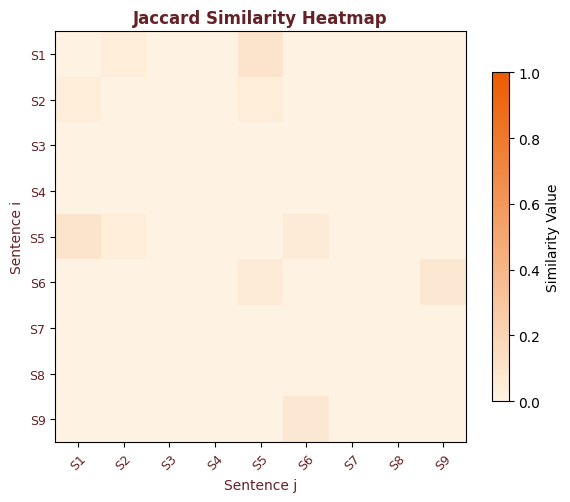

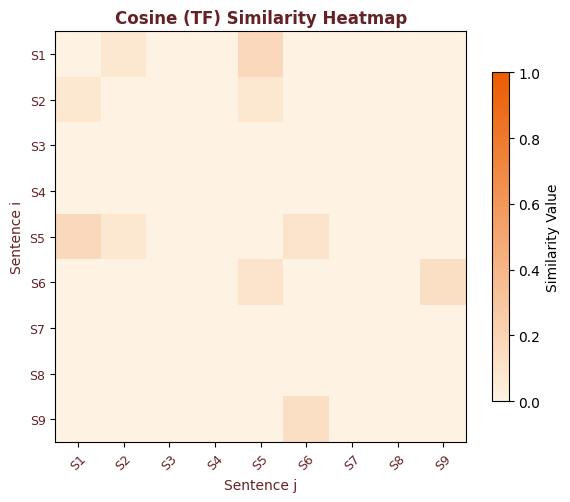

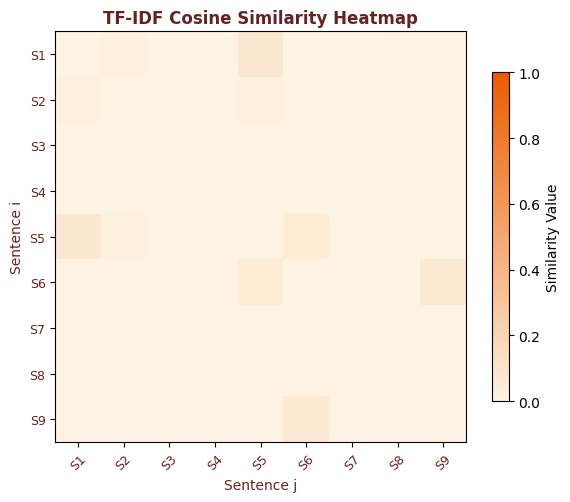

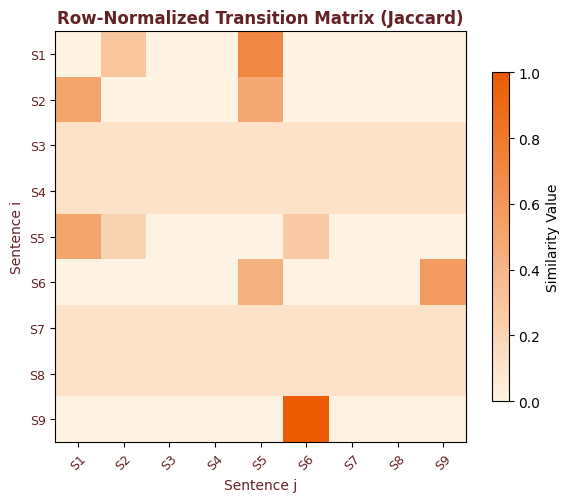

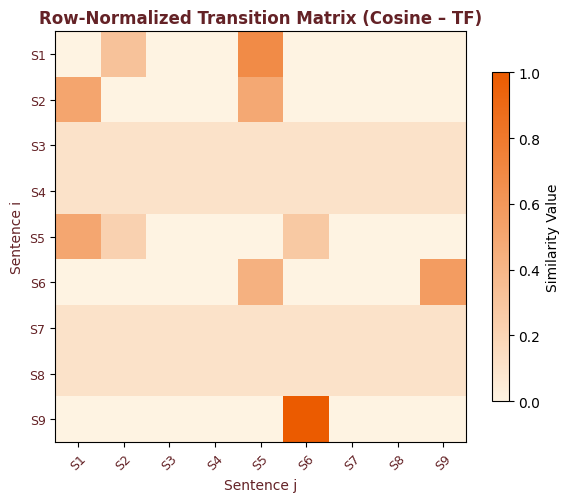

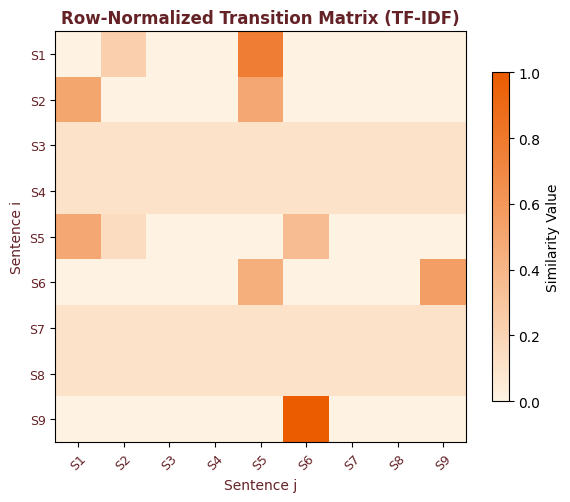

In [45]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- RUN PIPELINE ---
original_Articles, cleaned_tokens = preprocess_text_manual(article_text_input)

# Build all three similarity matrices
M_jac   = build_similarity_matrix(cleaned_tokens, metric="jaccard")
M_cos   = build_similarity_matrix(cleaned_tokens, metric="cosine")
M_tfidf = build_similarity_matrix(cleaned_tokens, metric="tfidf")

# Normalize all three (for TextRank transitions)
P_jac   = row_normalize(M_jac)
P_cos   = row_normalize(M_cos)
P_tfidf = row_normalize(M_tfidf)


# --- PRINT UTILITY ---
def print_matrix(matrix, title):
    print(f"\n{title}")
    n = len(matrix)
    for i in range(n):
        row_str = " | ".join(f"{val:.3f}" for val in matrix[i])
        print(f"Row {i+1}: {row_str}")


# --- DISPLAY SENTENCES FOR REFERENCE ---
print("\nOriginal Sentences:")
for i, s in enumerate(original_Articles):
    print(f"S{i+1}: {s}")

# --- PRINT NUMERIC MATRICES ---
print_matrix(M_jac,   "\n🔸 Jaccard Similarity Matrix")
print_matrix(M_cos,   "\n🔸 Cosine (TF) Similarity Matrix")
print_matrix(M_tfidf, "\n🔸 TF-IDF Cosine Similarity Matrix")

print_matrix(P_jac,   "\n🔹 Row-Normalized Transition Matrix – Jaccard")
print_matrix(P_cos,   "\n🔹 Row-Normalized Transition Matrix – Cosine (TF)")
print_matrix(P_tfidf, "\n🔹 Row-Normalized Transition Matrix – TF-IDF")


# --- VISUALIZATION SECTION ---
THEME_COLORS = ["#FEF3E2", "#EB5B00"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("theme_cmap", THEME_COLORS)

def plot_heatmap(matrix, title, labels):
    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, cmap=custom_cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(title, fontsize=12, fontweight="bold", color="#642226")
    plt.colorbar(label="Similarity Value", shrink=0.8)
    plt.xticks(range(len(labels)), [f"S{i+1}" for i in range(len(labels))],
               rotation=45, fontsize=9, color="#642226")
    plt.yticks(range(len(labels)), [f"S{i+1}" for i in range(len(labels))],
               fontsize=9, color="#642226")
    plt.xlabel("Sentence j", fontsize=10, color="#642226")
    plt.ylabel("Sentence i", fontsize=10, color="#642226")
    plt.tight_layout()
    plt.show()


# --- VISUALIZE ALL MATRICES ---
plot_heatmap(M_jac,   "Jaccard Similarity Heatmap", original_Articles)
plot_heatmap(M_cos,   "Cosine (TF) Similarity Heatmap", original_Articles)
plot_heatmap(M_tfidf, "TF-IDF Cosine Similarity Heatmap", original_Articles)

plot_heatmap(P_jac,   "Row-Normalized Transition Matrix (Jaccard)", original_Articles)
plot_heatmap(P_cos,   "Row-Normalized Transition Matrix (Cosine – TF)", original_Articles)
plot_heatmap(P_tfidf, "Row-Normalized Transition Matrix (TF-IDF)", original_Articles)



### **TextRank Iteration**

##### **Biulding Graph with Normlized Matrix**

In [46]:
# TextRank class-based graph

class Node:
    def __init__(self, idx):
        self.id = idx        #sentence index
        self.edges = []      #who it connects to and hoew much weight
        self.sum_w = 0.0     #Total strength of its connections

    def add_edge(self, j, w):
        self.edges.append((j, w))
        self.sum_w += w

class Graph:
    def __init__(self, n):
        self.n = n          #number of nodes
        self.nodes = []     # Creating nodes
        for i in range(n):
            self.nodes.append(Node(i))

    def build_from_matrix(self, M, tau=0.0):
        """
        Biuld graph from similarity matrix M, with optional threshold tau.
        """
        n = self.n
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue

                w = M[i][j]

                if tau == 0.0:
                    if w > 0.0:
                        self.nodes[i].add_edge(j, w)
                else:
                    if w >= tau and w > 0.0:
                        self.nodes[i].add_edge(j, w)

    def to_transition_matrix(self):
        """
        Convert weighted edges to row-stochastic probabilities.
        """
        n = self.n
        P = [[0.0 for _ in range(n)] for _ in range(n)]

        for i in range(n):
            node = self.nodes[i]

            if node.sum_w == 0.0:
                # Distribute probability uniformly
                val = 1.0 / n if n > 0 else 0.0
                for j in range(n):
                    P[i][j] = val
            else:
                # Normalize weights
                inv_sum = 1.0 / node.sum_w
                for edge in node.edges:
                    j = edge[0]
                    w = edge[1]
                    P[i][j] = w * inv_sum

        return P



In [47]:
# Example usage
original_Articles, cleaned_tokens = preprocess_text_manual(article_text_input)
M_tfidf = build_similarity_matrix(cleaned_tokens, metric="tfidf")

G = Graph(len(M_tfidf))
G.build_from_matrix(M_tfidf, tau=0.0)   # <-- tau=0.0 to mirror row_normalize
P_class = G.to_transition_matrix()

print("\nP:")
for i in range(len(P_class)):
    print(" ".join(f"{v:.2f}" for v in P_class[i]))




P:
0.00 0.23 0.00 0.00 0.77 0.00 0.00 0.00 0.00
0.51 0.00 0.00 0.00 0.49 0.00 0.00 0.00 0.00
0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11
0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11
0.50 0.15 0.00 0.00 0.00 0.36 0.00 0.00 0.00
0.00 0.00 0.00 0.00 0.44 0.00 0.00 0.00 0.56
0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11
0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.11
0.00 0.00 0.00 0.00 0.00 1.00 0.00 0.00 0.00


In [48]:
# ========= Graph Visualization =========

import math
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def _labels_from_sentences(sentences):
    if sentences is None:
        return [f"S{i+1}" for i in range(len(sentences))]
    return [f"S{i+1}" for i in range(len(sentences))]

def visualize_graph_from_matrix(M, sentences=None, title="Graph", tau=0.0, directed=False,
                                layout="spring", node_size=900, node_color="#f5efe6",
                                node_edge="#333333", label_color="#333333",
                                edge_min_width=0.5, edge_max_width=6.0, cmap="viridis",
                                show_colorbar=True, seed=42):

    n = len(M)
    labels = [f"S{i+1}" for i in range(n)]

    # Build graph
    G = nx.DiGraph() if directed else nx.Graph()
    G.add_nodes_from(range(n))
    edges = matrix_to_edges(M, tau=tau, directed=directed)
    for i, j, w in edges:
        G.add_edge(i, j, weight=w)

    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(G, seed=seed)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G, weight="weight")
    elif layout == "circular":
        pos = nx.circular_layout(G)
    elif layout == "shell":
        pos = nx.shell_layout(G)
    else:
        pos = nx.spring_layout(G, seed=seed)

    # Edge attributes
    weights = [G[u][v]["weight"] for u, v in G.edges()]
    if not weights:
        fig, ax = plt.subplots(figsize=(5,4))
        nx.draw_networkx(G, pos, with_labels=True,
                         labels={i: labels[i] for i in range(n)},
                         node_size=node_size, node_color=node_color,
                         edgecolors=node_edge, font_color=label_color,
                         arrows=directed, ax=ax)
        ax.set_title(f"{title} (no edges ≥ τ={tau})")
        ax.axis("off")
        plt.show()
        return

    w_min, w_max = min(weights), max(weights)

    def scale_w(w):
        if math.isclose(w_max, w_min):
            return (edge_min_width + edge_max_width) / 2.0
        return edge_min_width + (w - w_min) * (edge_max_width - edge_min_width) / (w_max - w_min)

    widths = [scale_w(w) for w in weights]

    norm = Normalize(vmin=w_min, vmax=w_max, clip=True)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    edge_colors = [sm.to_rgba(w) for w in weights]

    # Draw (Colab-safe)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    nx.draw_networkx_nodes(G, pos,
                           node_size=node_size, node_color=node_color,
                           edgecolors=node_edge, linewidths=1.2, ax=ax)

    nx.draw_networkx_labels(G, pos,
                            labels={i: labels[i] for i in range(n)},
                            font_color=label_color, font_size=10,
                            font_weight="bold", ax=ax)

    nx.draw_networkx_edges(G, pos,
                           width=widths, edge_color=edge_colors,
                           arrows=directed, arrowstyle="-|>", arrowsize=14,
                           connectionstyle="arc3,rad=0.08", ax=ax)

    if show_colorbar:
        cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label("Edge weight")

    ax.set_title(f"{title} (τ={tau}, {'Directed' if directed else 'Undirected'})", fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3268632393.py:81: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos,
/tmp/ipython-input-3268632393.py:81: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos,
/tmp/ipython-input-3268632393.py:81: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatche

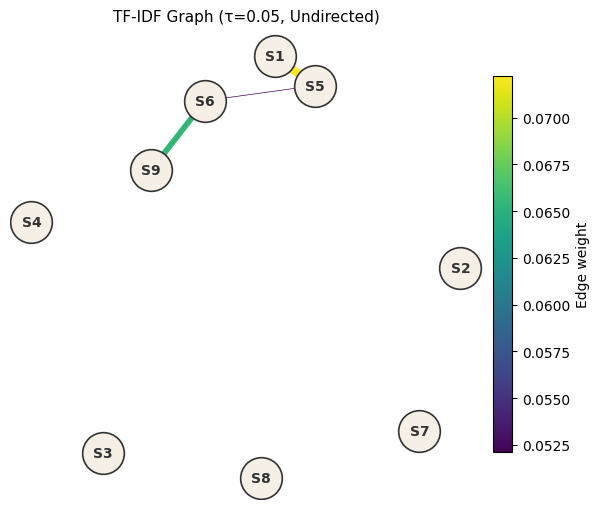

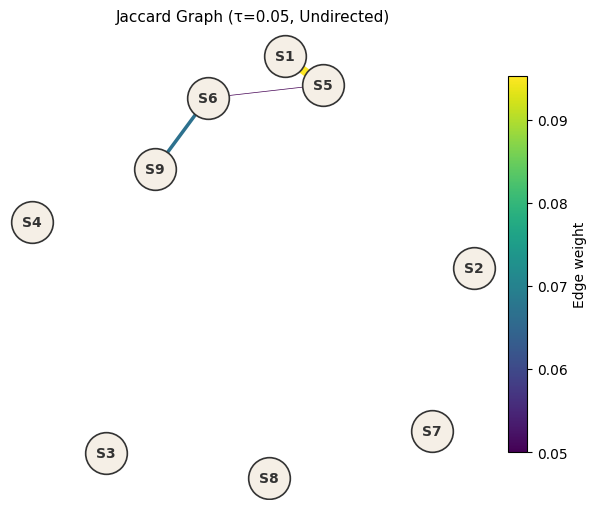

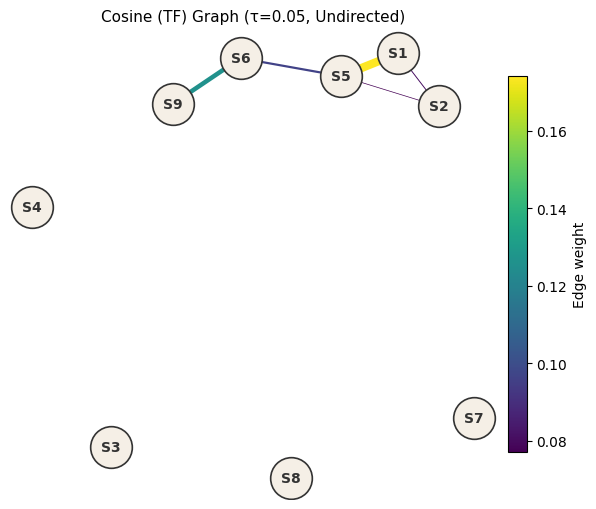

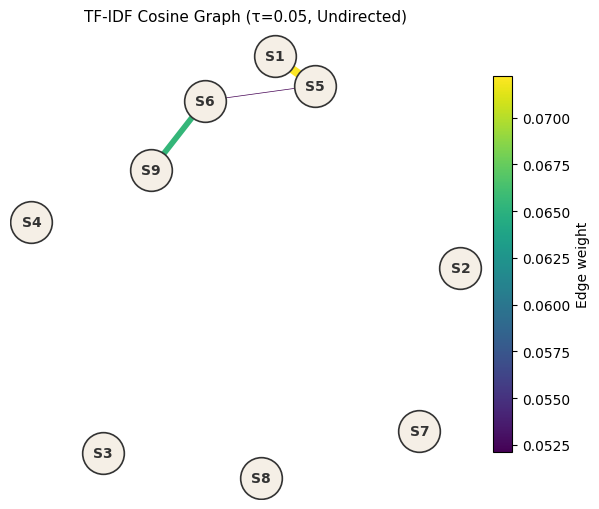

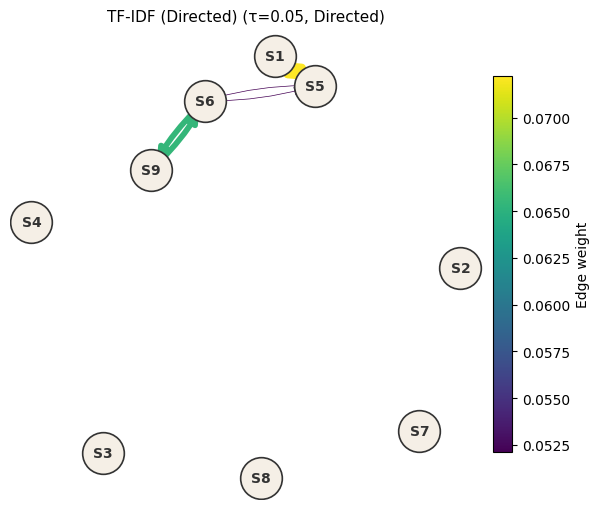

In [49]:
# --- VISUALIZE GRAPHS FROM SIMILARITY MATRICES ---
#visualize_graph_from_matrix(M_jaccard,   sentences=original_Articles, title="Jaccard Graph",   tau=0.05, directed=False)
#visualize_graph_from_matrix(M_cosine,   sentences=original_Articles, title="Cosine (TF) Graph", tau=0.05, directed=False)
visualize_graph_from_matrix(M_tfidf, sentences=original_Articles, title="TF-IDF Graph",    tau=0.05, directed=False)

visualize_all_three(M_jac, M_cos, M_tfidf, sentences=original_Articles, tau=0.05, directed=False, layout="spring")

visualize_graph_from_matrix(M_tfidf, sentences=original_Articles, title="TF-IDF (Directed)", tau=0.05, directed=True)


### **TextRank Algorithm**

In [50]:
# -------- TextRank Algorithm  --------

class TextRank:
    """
    Implements the TextRank algorithm for sentence ranking.
    Uses manual matrix operations.
    """
    def __init__(self, P, d=0.85, eps=1e-6, max_iter=100):
        self.P = P          # Transition matrix
        self.n = len(P)     # Number of nodes
        self.d = d          # Damping factor
        self.eps = eps
        self.max_iter = max_iter

        # Uniform initialization
        if self.n > 0:
            self.r = [1.0 / self.n] * self.n   # Initial rank vector: every node's ranks is equal to 1/N
        else:
            self.r = []

        self.history = []

    def iterate(self):
        if self.n == 0:                    #With probability (1-d), jump to any sentence randomly.
            return []
        teleport = (1.0 - self.d) / self.n

        for _ in range(self.max_iter):     #outer loop for iterations rt+1 -> rt
            r_next = [teleport] * self.n   #So every sentence starts with a small base score.

            for i in range(self.n):
                ri = self.r[i]            #Sentence i has importance ri
                row = self.P[i]           #Get its outgoing edges

                if ri == 0:
                    continue

                for j in range(self.n):
                    if row[j] > 0:
                        r_next[j] += self.d * ri * row[j]   #How much it contributes to sentence j usin matrix P

            # Compute L1 Convergence
            diff = 0.0
            for j in range(self.n):
                diff += abs(r_next[j] - self.r[j])    # Sum of absolute differences

            self.history.append(diff)

            self.r = r_next
            if diff < self.eps:                        # Converged (Stop here)
                break

        self._normalize()
        return self.r

    def _normalize(self):
        """Normalize rank vector to sum to 1"""
        total_score = sum(self.r)
        if total_score > 0.0:
            inv_total = 1.0 / total_score
            self.r = [v * inv_total for v in self.r]


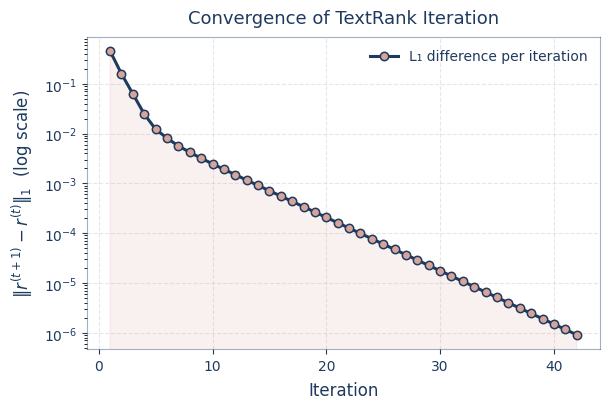

In [51]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- 1. Generate P (Transition Matrix) ---
# Ensure you have your input text ready
if 'article_text_input' not in locals():
    # Fallback text if not defined
    article_text_input = (
        "City officials unveiled a plan to renovate the park. "
        "The park is a popular spot for families. "
        "Residents agreed the upgrades were needed."
    )

# Preprocess and get tokens
_, tokens = preprocess_text_manual(article_text_input)

# Build Similarity Matrix (e.g., using TF-IDF metric)
M = build_similarity_matrix(tokens, metric="tfidf")

# Create Transition Matrix P by normalizing rows of M
# (This ensures the sum of probabilities in each row equals 1)
P = row_normalize(M)

# --- 2. Run TextRank and Visualize ---
# Project color palette
deepblue = "#1e3a5f"
goldenorange = "#d7a49a"

# Initialize and run TextRank
textrank = TextRank(P)
scores = textrank.iterate()
history = textrank.history

if not history:
    print("⚠️ No convergence data available. Run textrank.iterate() first.")
else:
    plt.figure(figsize=(6.2, 4.2))

    # Plot main curve
    plt.plot(
        range(1, len(history) + 1),
        history,
        marker='o',
        markersize=6,
        markerfacecolor=goldenorange,
        markeredgecolor=deepblue,
        markeredgewidth=1.1,
        color=deepblue,
        linewidth=2.2,
        label="L₁ difference per iteration"
    )

    plt.fill_between(
        range(1, len(history) + 1),
        history,
        color=goldenorange,
        alpha=0.15
    )

    plt.yscale('log')

    plt.xlabel("Iteration", fontsize=12, color=deepblue, labelpad=6)
    plt.ylabel(r"$\|r^{(t+1)} - r^{(t)}\|_1$  (log scale)", fontsize=12, color=deepblue, labelpad=6)
    plt.title("Convergence of TextRank Iteration", fontsize=13, color=deepblue, pad=10)

    plt.grid(alpha=0.3, linestyle='--')
    plt.tick_params(colors=deepblue, labelsize=10)

    for spine in plt.gca().spines.values():
        spine.set_edgecolor(deepblue)
        spine.set_alpha(0.4)

    plt.legend(frameon=False, fontsize=10, loc='upper right', labelcolor=deepblue)
    plt.tight_layout()

    plt.show()

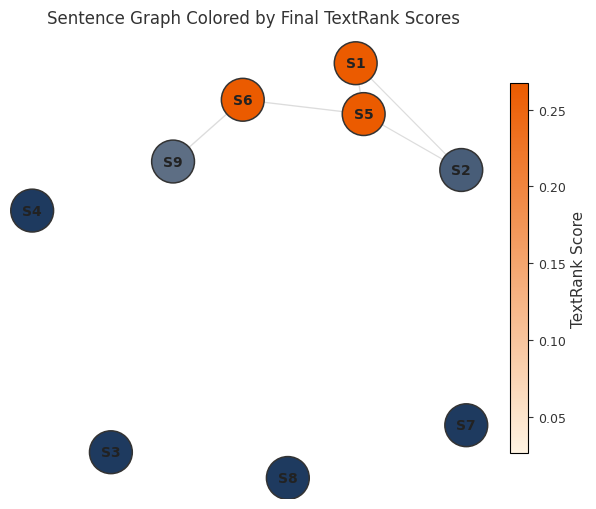

Saved textrank_scores_heatmap.png


In [52]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))

# Nodes
nx.draw_networkx_nodes(
    G_nx, pos,
    node_color=node_colors,
    node_size=950,
    edgecolors="#333333",
    linewidths=1.1,
    ax=ax
)

# Edges
nx.draw_networkx_edges(
    G_nx, pos,
    edge_color="#d9d9d9",
    width=[0.8 + 3.0 * G_nx[u][v]['weight'] for u, v in G_nx.edges()],
    alpha=0.9,
    ax=ax
)

# Labels
nx.draw_networkx_labels(
    G_nx, pos,
    labels={i: f"S{i+1}" for i in range(n)},
    font_size=10,
    font_weight="bold",
    font_color="#222222",
    ax=ax
)

sm = plt.cm.ScalarMappable(
    norm=plt.Normalize(vmin=r_arr.min(), vmax=r_arr.max()),
    cmap=cmap
)

cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("TextRank Score", fontsize=11, color="#333333")
cbar.ax.tick_params(labelsize=9, colors="#333333")

ax.set_title("Sentence Graph Colored by Final TextRank Scores",
             fontsize=12, color="#333333", pad=10)
ax.axis("off")
plt.tight_layout()
plt.savefig("textrank_scores_heatmap.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

print("Saved textrank_scores_heatmap.png")


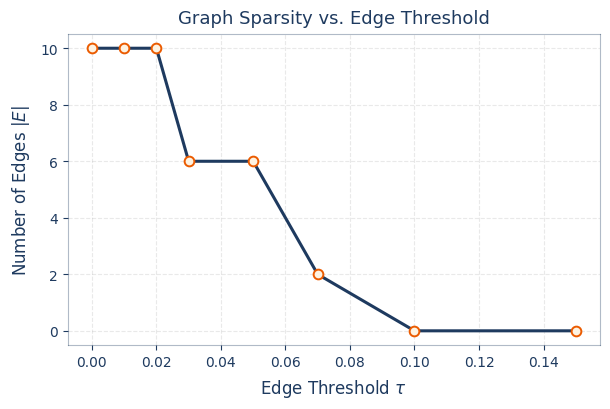

✅ Saved styled plot -> fig_tau_edges.png


In [53]:
# visualization of GRAPH SPARSITY vs EDGE THRESHOLD  ======
import matplotlib.pyplot as plt
import numpy as np

def plot_edges_vs_tau_styled_class_based(token_lists, metric="tfidf", save_path="fig_tau_edges.png"):
    """
    Plot how the number of edges |E| changes with threshold τ, using your class-based Graph.
    """
    deepblue      = "#1e3a5f"
    goldenorange  = "#EB5B00"
    lightbeige    = "#FEF3E2"

    M = build_similarity_matrix(token_lists, metric=metric)
    n = len(token_lists)

    taus = [0.00, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15]
    edge_counts = []

    for tau in taus:
        G = Graph(n)
        G.build_from_matrix(M, tau=tau)
        total_edges = 0
        i = 0
        while i < n:
            total_edges += len(G.nodes[i].edges)
            i += 1
        edge_counts.append(total_edges)

    # --- Plot setup ---
    plt.figure(figsize=(6.2, 4.2))

    # Main curve
    plt.plot(
        taus, edge_counts,
        marker='o',
        markersize=7,
        markerfacecolor=lightbeige,
        markeredgecolor=goldenorange,
        markeredgewidth=1.4,
        linewidth=2.2,
        color=deepblue
    )

    plt.xlabel(r"Edge Threshold $\tau$", fontsize=12, color=deepblue, labelpad=6)
    plt.ylabel(r"Number of Edges $|E|$", fontsize=12, color=deepblue, labelpad=6)
    plt.title("Graph Sparsity vs. Edge Threshold", fontsize=13, color=deepblue, pad=8)

    plt.grid(alpha=0.28, linestyle='--')
    plt.tick_params(colors=deepblue, labelsize=10)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor(deepblue)
        spine.set_alpha(0.35)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False)
    plt.show()

    print(f"✅ Saved styled plot -> {save_path}")


plot_edges_vs_tau_styled_class_based(cleaned_tokens, metric="tfidf", save_path="fig_tau_edges.png")




### **Sorting the textrank scores**

In [54]:
#---------- MMR Top-k Selector ----------

class MMRSelector:
    """
    Algorithmic Maximal Marginal Relevance (MMR) selector.
    Selects sentences based on a trade-off between Relevance (TextRank score)
    and Diversity (dissimilarity to already selected sentences).
    """
    def __init__(self, sentences, tokens_list, scores, metric="tfidf"):
        self.sentences = sentences
        self.tokens_list = tokens_list
        self.scores = scores
        self.metric = metric     #similarity metric for redundancy
        self.n = len(sentences)  # Use len() for O(1)
        self.sim_M = build_similarity_matrix(tokens_list, metric=metric) #simlarity matrix between sentences

    # ---------- vanila Top-k  ----------
    def select_top_k(self, k):
        """Returns top-k sentences based solely on TextRank score."""
        k = min(k, self.n)      #never ask for more sentences than exist.
        if k <= 0:
            return [], []


        indexed_scores = []     # Create (index, score) pairs
        for i in range(self.n):
            indexed_scores.append((i, self.scores[i]))

        # Standard Python Sort (Timsort is O(N log N))
        indexed_scores.sort(key=lambda x: x[1], reverse=True)

        # Extract top k
        top_indices = [x[0] for x in indexed_scores[:k]]

        # Restore original document order (optional, but usually preferred for summaries)
        top_indices.sort()

        out_sents = [self.sentences[i] for i in top_indices]
        return top_indices, out_sents

    # ---------- MMR Top-k (Relevance + Diversity) ----------
    def select_top_k_mmr(self, k, lam=0.8):
        """
        Iteratively select k sentences maximizing:
        MMR = lambda * Score - (1-lambda) * MaxSim(candidate, selected)
        """
        k = min(k, self.n)
        if k <= 0:
            return [], []      # Make sure k is valid

        # Clamp lambda
        lam = max(0.0, min(1.0, lam))

        selected = []         #S is empty at start

        for _ in range(k):
            best_candidate = -1
            best_mmr_score = -float('inf')

            for i in range(self.n):
                if i in selected:
                    continue           #Skip already selected ones

                # Calculate Redundancy (Similarity to already selected)(The seccond term in MMR)
                redundancy = 0.0            #assume no redundancy at start
                if selected:
                    for j in selected:
                        sim = self.sim_M[i][j]
                        if sim > redundancy:    #max sim (i,j) for j in selected
                            redundancy = sim

                # MMR Formula
                mmr_score = (lam * self.scores[i]) - ((1 - lam) * redundancy)

                if mmr_score > best_mmr_score:  #Maximize MMR
                    best_mmr_score = mmr_score
                    best_candidate = i

            if best_candidate != -1:
                selected.append(best_candidate)

        # Sort indices to present summary in narrative order
        selected.sort()
        out_sents = [self.sentences[i] for i in selected]
        return selected, out_sents



In [55]:
# --- Building MAtrixes we will need in the futurwe steps ---
G = Graph(n=len(cleaned_tokens))         #Creates a graph with one node per sentence.
G.build_from_matrix(M_tfidf, tau=0.0)    #Builds edges based on the TF-IDF similarity matrix (no threshold).
P_tfidf = G.to_transition_matrix()       #Converts the graph's edges into a row-stochastic transition matrix.

textrank = TextRank(P_tfidf, d=0.85, eps=1e-6, max_iter=100)  #Initializes TextRank alg.
scores = textrank.iterate()                                   #Runs TextRank to get sentence scores.


selector = MMRSelector(original_Articles, cleaned_tokens, scores, metric="tfidf") #Initialize MMR selector
idx_plain, summary_plain = selector.select_top_k(k=3)

# --- MMR with TF-IDF redundancy  ---
idx_mmr, summary_mmr = selector.select_top_k_mmr(k=3, lam=0.75)

# --- MMR with Jaccard redundancy  ---
selector_j = MMRSelector(original_Articles, cleaned_tokens, scores, metric="jaccard")
idx_mmr_j, summary_mmr_j = selector_j.select_top_k_mmr(k=3, lam=0.8)




### **Runing Together**

In [56]:
def summarize_textrank(
    article_text,
    k=3,
    metric="tfidf",
    d=0.85,
    tau=0.05,           # edge threshold
    use_mmr=False,
    lam=0.8,
    return_all=False
):
    """
    Run full TextRank summarization pipeline.
    Orchestrates Preprocessing -> Similarity -> Graph -> Rank -> Selection.
    """

    # 1) --- Preprocessing ---
    sentences, tokens_list = preprocess_text_manual(article_text)
    n = len(sentences)

    # Handle empty text edge case
    if n == 0:
        empty_res = ([], [], [], [], None)
        return (*empty_res, []) if return_all else empty_res

    # clamp k
    k = max(1, min(k, n))

    # 2) --- Similarity matrix ---
    M = build_similarity_matrix(tokens_list, metric=metric)

    # 3) --- Graph + Transition matrix ---
    G = Graph(n)
    G.build_from_matrix(M, tau=tau)
    P = G.to_transition_matrix()

    # 4) --- TextRank iteration ---
    textrank = TextRank(P, d=d, eps=1e-6, max_iter=100)
    scores = textrank.iterate()

    # 5) --- Sentence selection ---
    selector = MMRSelector(sentences, tokens_list, scores, metric=metric)

    if use_mmr:
        idx, summary = selector.select_top_k_mmr(k=k, lam=lam)
    else:
        idx, summary = selector.select_top_k(k=k)

    # 6) --- Return results ---
    if not return_all:
        return idx, summary, scores, P, G

    ranked_idx = list(range(n))
    # Sort descending by score using standard Python sort
    ranked_idx.sort(key=lambda i: scores[i], reverse=True)

    return idx, summary, scores, P, G, ranked_idx



In [57]:
# Varying tau values experiment

tau_values = [0.0, 0.05, 0.1, 0.2]

for tau_val in tau_values:
    print("\n" + "="*64)
    print(f"======== RUN with tau = {tau_val:.2f} ========")

    idx_run, summary_run, scores_run, P_run, G_run = summarize_textrank(
        article_text_input,
        k=3,                       # top-3 sentences
        metric="tfidf",            # "tfidf" | "cosine" | "jaccard"
        d=0.85,                    # damping factor
        tau=tau_val,               # prune weak edges below tau
        use_mmr=True,              # activate redundancy control
        lam=0.8                    # trade-off parameter
    )

    # --- Display summary output ---
    print("\n TEXT RANK SUMMARY (rank order):")
    for s in summary_run:
        print("•", s)

    # --- Display node-level (sentence) importance scores ---
    print("\n NODE SCORES (TextRank):")
    for i, sc in enumerate(scores_run):
        print(f"S{i+1}: {sc:.4f}")

    # --- Display graph statistics ---
    num_nodes = len(P_run)  # O(1)

    num_edges = sum(len(node.edges) for node in G_run.nodes)

    print("\n GRAPH STATISTICS:")
    print(f"Number of sentences (|V|): {num_nodes}")
    print(f"Number of directed edges (|E|): {num_edges}")
    print(f"Edge threshold (tau): {tau_val}")
    print(f"Damping factor (d): 0.85")
    print(f"Redundancy control (MMR): True  (lambda = 0.8)")

    print("\nSelected sentence indices (rank order):", idx_run)
    sorted_idx = sorted(idx_run)
    print("Selected sentence indices (original order):", sorted_idx)



print("\n" + "="*64)
print("Experiment complete. Compare how summaries differ across tau values.")




======== RUN with tau = 0.00 ========

 TEXT RANK SUMMARY (rank order):
• City officials unveiled a €2.5-million plan to renovate Greenfield Park by May 2026.
• Officials argued that phased work keeps most areas open and makes the park safer after dark.
• Parents repeated that the improvements will make evenings safer and more enjoyable for children.

 NODE SCORES (TextRank):
S1: 0.1806
S2: 0.0962
S3: 0.0268
S4: 0.0268
S5: 0.2672
S6: 0.2186
S7: 0.0268
S8: 0.0268
S9: 0.1302

 GRAPH STATISTICS:
Number of sentences (|V|): 9
Number of directed edges (|E|): 10
Edge threshold (tau): 0.0
Damping factor (d): 0.85
Redundancy control (MMR): True  (lambda = 0.8)

Selected sentence indices (rank order): [0, 4, 5]
Selected sentence indices (original order): [0, 4, 5]

======== RUN with tau = 0.05 ========

 TEXT RANK SUMMARY (rank order):
• City officials unveiled a €2.5-million plan to renovate Greenfield Park by May 2026.
• Officials argued that phased work keeps most areas open and makes the pa

In [58]:
#COMPARISON SUMMARY (across tau values)

tau_values = [0.0, 0.05, 0.1, 0.2]

print("\n" + "="*80)
print("COMPARISON OF RESULTS ACROSS TAU VALUES")
print("="*80)
print(f"{'Tau':<8} {'|E| (edges)':<14} {'Top-3 Sentences (indices)':<30} {'Top-1 Sentence ID':<20}")
print("-" * 80)

# run summarize_textrank once for each tau, collect quick stats
for tau_val in tau_values:
    idx_run, summary_run, scores_run, P_run, G_run = summarize_textrank(
        article_text_input,
        k=3,
        metric="tfidf",
        d=0.85,
        tau=tau_val,
        use_mmr=True,
        lam=0.8
    )

    # --- Count edges efficiently (O(N)) ---
    num_edges = sum(len(node.edges) for node in G_run.nodes)

    # --- Get Top-1 Sentence ID efficiently ---
    max_score = max(scores_run)
    # finding index of max score
    top1_id = scores_run.index(max_score)

    # make a compact string of top-k indices
    topk_str = ', '.join(str(i) for i in idx_run)

    print(f"{tau_val:<8.2f} {num_edges:<14} {topk_str:<30} {top1_id:<20}")

print("-" * 80)
print("Table shows how graph sparsity (|E|) and top-ranked sentences change with tau.")
print("Note: Fewer edges = sparser graph = more selective connections.")


COMPARISON OF RESULTS ACROSS TAU VALUES
Tau      |E| (edges)    Top-3 Sentences (indices)      Top-1 Sentence ID   
--------------------------------------------------------------------------------
0.00     10             0, 4, 5                        4                   
0.05     6              0, 4, 5                        4                   
0.10     0              0, 2, 3                        0                   
0.20     0              0, 2, 3                        0                   
--------------------------------------------------------------------------------
Table shows how graph sparsity (|E|) and top-ranked sentences change with tau.
Note: Fewer edges = sparser graph = more selective connections.


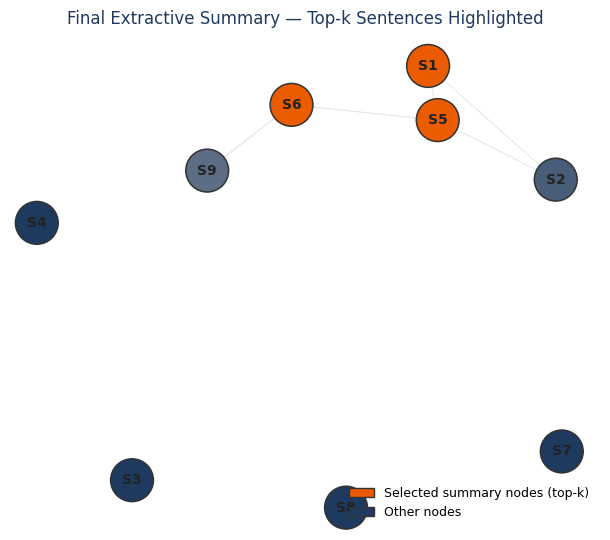

In [59]:
# Visualization of final summary with highlighted top-k sentences
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np

deepblue = "#1e3a5f"
goldenorange = "#EB5B00"
lightbeige = "#FEF3E2"
neutralgray = "#b5b5b5"


n = G.n
r_arr = np.array(scores)

# --- Build networkx Graph from your Graph object ---
G_nx = nx.Graph()
G_nx.add_nodes_from(range(n))

for node in G.nodes:
    for j, w in node.edges:
        G_nx.add_edge(node.id, j, weight=w)

# --- Layout and normalize ranks ---
pos = nx.spring_layout(G_nx, seed=42)
r_norm = (r_arr - r_arr.min()) / (r_arr.max() - r_arr.min() + 1e-12)

# --- Select top-k nodes ---
top_k = 3
top_ids = np.argsort(r_arr)[::-1][:top_k]

# --- Define node colors ---
node_colors = []
for i in range(n):
    if i in top_ids:
        node_colors.append(goldenorange)
    else:
        blend = 0.35 + 0.65 * (1 - r_norm[i])
        node_colors.append(mcolors.to_hex(
            np.array(mcolors.to_rgb(deepblue)) * blend +
            np.array(mcolors.to_rgb(lightbeige)) * (1 - blend)
        ))


# --- Draw graph ---
plt.figure(figsize=(6.2, 5.5))
edge_widths = [0.6 + 2.8 * G_nx[u][v]['weight'] for u, v in G_nx.edges()]

# Edges (background)
nx.draw_networkx_edges(
    G_nx, pos,
    edge_color="#dddddd",
    width=edge_widths,
    alpha=0.8
)

# Nodes
nx.draw_networkx_nodes(
    G_nx, pos,
    node_color=node_colors,
    edgecolors="#333333",
    linewidths=1.1,
    node_size=950
)

# Labels
nx.draw_networkx_labels(
    G_nx, pos,
    labels={i: f"S{i+1}" for i in range(n)},
    font_size=10,
    font_weight="bold",
    font_color="#222222"
)

# --- Legend ---
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=goldenorange, edgecolor="#333333", label="Selected summary nodes (top-k)"),
    Patch(facecolor=deepblue, edgecolor="#333333", label="Other nodes")
]
plt.legend(handles=legend_elems, loc="lower right", frameon=False, fontsize=9)

# --- Final touches ---
plt.title("Final Extractive Summary — Top-k Sentences Highlighted",
          fontsize=12, color=deepblue, pad=10)
plt.axis("off")
plt.tight_layout()
plt.savefig("textrank_summary_graph_colored.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()




### **Results**

In [60]:
# APPLY SUMMARIZER TO ENTIRE toy_set (class-based, proportional k) ======

def auto_k_for_proportional(sent_count, alpha=0.25, k_min=1, k_max=3):
    """Decide k ≈ alpha * n, clamped to [k_min, k_max]."""
    if sent_count <= 0:
        return 0
    k = int(round(alpha * sent_count))
    return max(k_min, min(k_max, min(k, sent_count)))


def summarize_row_text_class_based(
    row_text,
    metric="tfidf",
    d=0.85,
    tau=0.05,
    use_mmr=True,
    lam=0.8
):
    """
    Wrapper that calls the main pipeline and formats output for DataFrame.
    """

    # 1. Determine N to calculate K (lightweight preprocess check)
    # We need a quick check for N to set K, but summarize_textrank does full preprocess.
    # To be efficient, we just run the pipeline and let it handle k internally?
    # No, we need to pass k. So we do a quick split.
    # OR better: We trust our main function to handle clamping.

    # Let's do a quick pre-calc for K
    # (We accept a tiny double-work on tokenization for the sake of clean architecture)
    dummy_sentences, _ = preprocess_text_manual(row_text)
    n = len(dummy_sentences)
    k = auto_k_for_proportional(n)

    idx, summary, scores, P, G = summarize_textrank(
        row_text,
        k=k,
        metric=metric,
        d=d,
        tau=tau,
        use_mmr=use_mmr,
        lam=lam
    )

    if G is None:
        edge_count = 0
        top_score = 0.0
    else:
        # Fast edge count using generator
        edge_count = sum(len(node.edges) for node in G.nodes)
        top_score = max(scores) if scores else 0.0

    return {
        "summary_indices": idx,
        "summary_sentences": summary,
        "sent_count": n,
        "edge_count": edge_count,
        "top_score": top_score,
    }


# --- Apply summarizer to each article in Articles ---
results = []
print("Processing Batch...")
for i in range(len(toy_set)):
    art = toy_set.loc[i, "article"]

    print(f" -> Article {i+1}/{len(toy_set)}...", end="\r")

    out = summarize_row_text_class_based(
        art, metric="tfidf", d=0.85, tau=0.05, use_mmr=True, lam=0.8
    )
    results.append(out)
print("\nDone.")

# --- Attach summaries and stats to DataFrame ---
toy_set["summary_indices"]   = [r["summary_indices"]   for r in results]
toy_set["summary_sentences"] = [r["summary_sentences"] for r in results]
toy_set["sent_count"]        = [r["sent_count"]        for r in results]
toy_set["edge_count"]        = [r["edge_count"]        for r in results]
toy_set["top_score"]         = [r["top_score"]         for r in results]

for i in range(len(toy_set)):
    print("\n" + "="*60)
    print(f"ARTICLE ID: {toy_set.loc[i, 'id']}")
    print(f"Stats: {toy_set.loc[i, 'sent_count']} sentences, {toy_set.loc[i, 'edge_count']} edges")
    print("TEXT RANK SUMMARY:")
    for s in toy_set.loc[i, "summary_sentences"]:
        print("•", s)
    print("\nREF HIGHLIGHT:", toy_set.loc[i, "highlights"])

print("\n" + "="*60)
print("Summarization complete for all rows in toy_set.")



Processing Batch...
 -> Article 5/5...
Done.

ARTICLE ID: ed0fed726929c1eeabe6c390e47128dbb7d7a055
Stats: 31 sentences, 196 edges
TEXT RANK SUMMARY:
• Sun's out: Brighton beach was packed with Britons enjoying the unexpected sunshine to start the long weekend as temperatures hit 17C across the south coast .
• Three day forecast: Tomorrow sunny spells and warm weather is set to cover southern England, but the heavy rain up north is set to stay .
• Though rain poured down in the north west, the north east enjoyed a bright spell at midday today with sun shining in Harrogate (pictured) ahead of the rainy weekend .

REF HIGHLIGHT: People enjoyed temperatures of 17C at Brighton beach in West Sussex and Weymouth in Dorset .
Asda claims it will sell a million sausages over long weekend despite night temperatures dropping to minus 1C .
But the good weather has not been enjoyed by all as the north west and Scotland have seen heavy rain .

ARTICLE ID: 023cd84001b33aed4ff0f3f5ecb0fdd2151cf543
Stat

### **Some more visuallizations for the report**

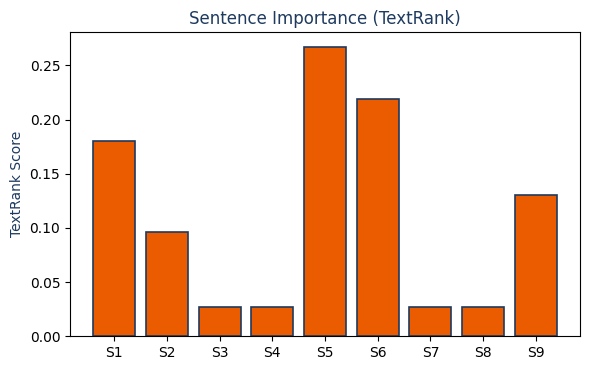

In [61]:
#Plot TextRank scores as bar chart
deepblue      = "#1e3a5f"
goldenorange  = "#EB5B00"
lightbeige    = "#FEF3E2"
def plot_textrank_scores(scores):
    x = range(len(scores))
    plt.figure(figsize=(6, 3.8))
    plt.bar(x, scores, color=goldenorange, edgecolor=deepblue, linewidth=1.2)
    plt.xticks(x, [f"S{i+1}" for i in x])
    plt.ylabel("TextRank Score", color=deepblue)
    plt.title("Sentence Importance (TextRank)", color=deepblue)
    plt.tight_layout()
    plt.savefig("fig_textrank_scores.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_textrank_scores(scores)


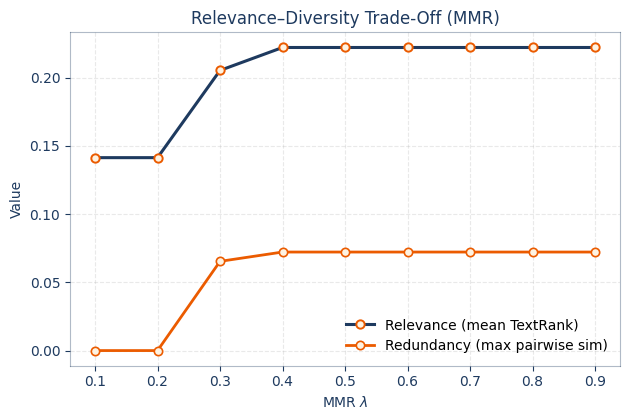

✅ Saved fig_mmr_tradeoff.png


In [62]:
#MMR TRADE-OFF CURVES
import itertools

# Theme
deepblue      = "#1e3a5f"
goldenorange  = "#EB5B00"
lightbeige    = "#FEF3E2"

def max_pairwise_sim(indices, simM):
    """Return the maximum pairwise similarity among the selected indices."""
    if len(indices) < 2:
        return 0.0
    m = 0.0
    for i, j in itertools.combinations(indices, 2):
        if simM[i][j] > m:
            m = simM[i][j]
    return m


def mmr_tradeoff_curves_class_based(sentences, tokens, scores, k=3, lambdas=None, metric="tfidf"):
    """Compute MMR trade-off curves using the class-based selector."""
    if lambdas is None:
        lambdas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

    # Precompute redundancy similarity matrix
    redund_sim = build_similarity_matrix(tokens, metric=metric)
    rel_vals, red_vals = [], []

    # Instantiate selector once
    selector = MMRSelector(sentences, tokens, scores, metric=metric)

    for lam in lambdas:
        idx, _ = selector.select_top_k_mmr(k=k, lam=lam)
        # relevance = mean TextRank score of selected sentences
        rel = sum(scores[i] for i in idx) / len(idx)
        # redundancy = max pairwise similarity among selected sentences
        red = max_pairwise_sim(idx, redund_sim)
        rel_vals.append(rel)
        red_vals.append(red)

    return lambdas, rel_vals, red_vals



lams, rel_vals, red_vals = mmr_tradeoff_curves_class_based(
    original_Articles, cleaned_tokens, scores, k=3, metric="tfidf"
)

plt.figure(figsize=(6.4, 4.3))

# Relevance curve
plt.plot(
    lams, rel_vals,
    marker='o',
    markerfacecolor=lightbeige,
    markeredgecolor=goldenorange,
    markeredgewidth=1.4,
    color=deepblue,
    linewidth=2.2,
    label="Relevance (mean TextRank)"
)

# Redundancy curve
plt.plot(
    lams, red_vals,
    marker='o',
    markerfacecolor=lightbeige,
    markeredgecolor=goldenorange,
    markeredgewidth=1.2,
    color=goldenorange,
    linewidth=2.0,
    label="Redundancy (max pairwise sim)"
)

plt.xlabel(r"MMR $\lambda$", color=deepblue)
plt.ylabel("Value", color=deepblue)
plt.title("Relevance–Diversity Trade-Off (MMR)", color=deepblue)
plt.grid(alpha=0.28, linestyle='--')
plt.tick_params(colors=deepblue, labelsize=10)
ax = plt.gca()
for s in ax.spines.values():
    s.set_edgecolor(deepblue)
    s.set_alpha(0.35)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig_mmr_tradeoff.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved fig_mmr_tradeoff.png")
